In [14]:
import preprocess
import numpy as np
import pandas as pd
import itertools
import scipy.stats as stats
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.linear_model import LinearRegression, Lasso, Ridge

In [15]:
preprocess_cfg : preprocess.PreprocessConfig = preprocess.PreprocessConfig.load_json("baseline.json")
opt_ridge_alpha = np.logspace(-4, 10, num=15)
opt_lasso_alpha = np.logspace(-4, 10, num=30)
opt_gl_alpha1 = [10 ** x for x in range(-2, 3)]
opt_gl_alpha2 = [10 ** x for x in range(-2, 3)]

print(opt_ridge_alpha)

[1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03 1.e+04 1.e+05
 1.e+06 1.e+07 1.e+08 1.e+09 1.e+10]


In [16]:
raw = preprocess.load_data(preprocess_cfg)

# Baseline

Use the save split from the baseline and compare performance of group lasso, lasso, ridge regression and Linear regression.

Applied log transform to 41 skewed features: 
- me: 14.671445653006721
- be_me: 56.167905625824055
- sale_me: 30.75236334966476
- ni_me: -67.3135899846856
- ocf_me: -66.31166461663669
- fcf_me: -199.7113287551048
- ebitda_mev: 634.7223730059752
- div12m_me: 80.57007821769282
- gp_at: 626.7547241149634
- ope_be: -346.5205857668452
- cop_at: -426.440494397733
- ocf_at: 651.6456002702166
- op_at: 545.7350450286839
- niq_be: 187.56337319689496
- ret_1_0: 1227.9142179398125
- ret_6_1: 866.7802011949768
- ret_12_1: 608.5589930420649
- ret_60_12: 90.98165737946113
- seas_1_1an: 261.32866066309776
- at_gr1: 723.6297395753427
- sale_gr1: 244.9161976740569
- capx_gr1: 723.4338475233931
- inv_gr1: 166.87091943447123
- noa_gr1a: 255.78923995854652
- ivol_capm_21d: 1198.7352959151976
- ivol_ff3_21d: 1204.9678049199647
- rvol_21d: 1190.577890953655
- rmax1_21d: 1215.5160306185194
- rmax5_21d: 1116.2686404220888
- dolvol: 39.26059593816976
- turnover_126d: 45.787153924314445
- ami_126d: 260.272389433

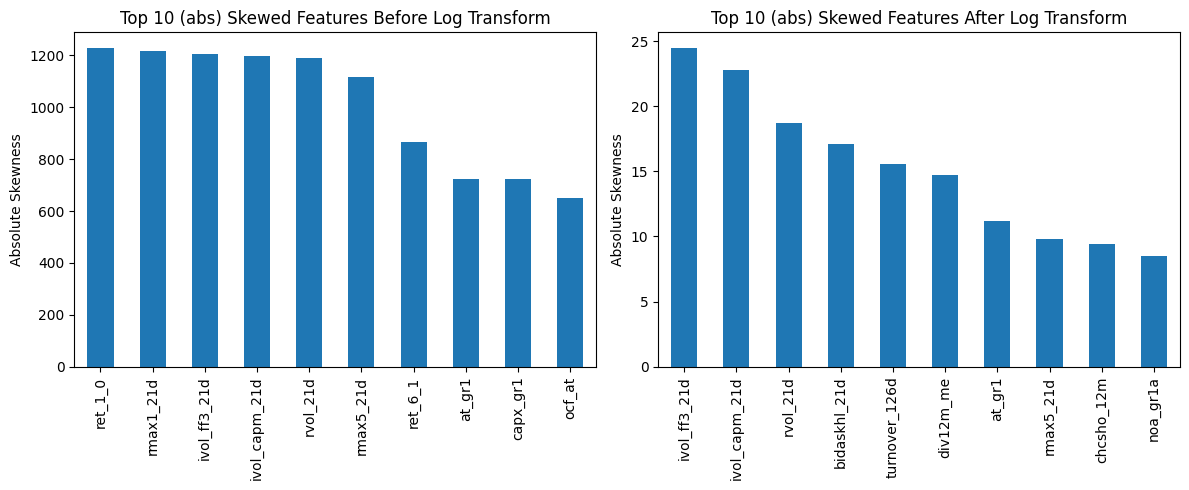

Index(['me', 'be_me', 'sale_me', 'ni_me', 'ocf_me', 'fcf_me', 'ebitda_mev',
       'div12m_me', 'gp_at', 'ope_be', 'cop_at', 'ocf_at', 'op_at', 'niq_be',
       'ret_1_0', 'ret_6_1', 'ret_12_1', 'ret_60_12', 'resff3_12_1',
       'seas_1_1an', 'at_gr1', 'sale_gr1', 'capx_gr1', 'inv_gr1', 'noa_gr1a',
       'emp_gr1', 'beta_60m', 'ivol_capm_21d', 'ivol_ff3_21d', 'rvol_21d',
       'rmax1_21d', 'rmax5_21d', 'rmax5_rvol_21d', 'dolvol', 'turnover_126d',
       'ami_126d', 'bidaskhl_21d', 'qmj', 'f_score', 'o_score', 'z_score',
       'oaccruals_at', 'taccruals_at', 'cash_at', 'chcsho_12m', 'eqnpo_12m',
       'netis_at', 'age', 'at_me', 'niq_su', 'mispricing_mgmt'],
      dtype='str')

In [17]:
train_df, val_df, test_df = preprocess.split(raw, preprocess_cfg)

train_df, val_df, test_df = preprocess.transform(train_df, val_df, test_df, preprocess_cfg, exclude=['excntry'])

X_train, y_train = preprocess.get_xy(train_df, preprocess_cfg, excludes=['excntry'])
X_val, y_val = preprocess.get_xy(val_df, preprocess_cfg, excludes=['excntry'])
X_test, y_test = preprocess.get_xy(test_df, preprocess_cfg, excludes=['excntry'])

X_train.columns

In [18]:
X_train.head(5)

,me,be_me,sale_me,ni_me,ocf_me,fcf_me,ebitda_mev,div12m_me,gp_at,ope_be,...,oaccruals_at,taccruals_at,cash_at,chcsho_12m,eqnpo_12m,netis_at,age,at_me,niq_su,mispricing_mgmt
0,-0.906755,-1.092322,-1.254144,-0.415391,-0.980777,-0.474688,-0.943659,-0.212828,-1.08086,-1.012235,...,1.789028,1.215328,0.247397,6.036399,-5.856524,3.863237,0.316726,-1.196768,0.00455,-2.595119
1,-0.785540,-0.447401,-1.224909,-0.492760,-0.993092,-0.409416,-1.026028,-0.212828,-1.08086,-1.012235,...,0.675748,1.215328,0.938055,6.036399,-5.856524,3.863237,0.324367,-0.505328,0.00455,-2.595119
2,-0.653921,-0.657565,-1.234201,-0.438514,-0.922520,-0.351548,-0.994837,-0.212828,-1.08086,-1.012235,...,0.675748,1.215328,0.938055,6.036399,-5.856524,3.863237,0.332008,-0.654885,0.00455,-2.595119
3,-0.638836,-0.679639,-1.235144,-0.433004,-0.915339,-0.345665,-0.991622,-0.212828,-1.08086,-1.012235,...,0.675748,1.215328,0.938055,6.036399,-5.856524,3.863237,0.339649,-0.670891,0.00455,-2.595119
4,-0.630044,-0.643603,-1.209036,-0.561394,-0.978138,-0.342303,-1.079083,-0.212828,-1.08086,-1.012235,...,0.545661,1.215328,0.938055,6.036399,-5.856524,3.863237,0.347290,-0.644791,0.00455,-2.595119


In [19]:
def print_eom_range(df : pd.DataFrame, name : str) :
	print(f"dataset {name:6s}: from {df['eom'].min().date()} to {df['eom'].max().date()}")

print_eom_range(train_df, "train")
print_eom_range(val_df, "val")
print_eom_range(test_df, "test")

dataset train : from 2005-01-31 to 2015-12-31
dataset val   : from 2016-01-31 to 2018-12-31
dataset test  : from 2019-01-31 to 2024-11-30


## Comparison of OLS, Ridge, Lasso and Group Lasso

In [20]:
def oos_r2(y_true, y_pred, y_null) -> np.ndarray :
	return 1 - np.mean((y_true - y_pred) ** 2) / np.mean((y_true - y_null) ** 2)

def portfolio_weights(pred, max_w = 0.05) :
	n = len(pred)
	w = pd.Series(pred).rank() - (n + 1) / 2
	w /= w.abs().sum() + 1e-8
	w = w.clip(-max_w, max_w)
	w /= w.abs().sum() + 1e-8
	return w.values

def compute_portfolio_metrics(df : pd.DataFrame, pred_col : str, cfg : preprocess.PreprocessConfig) -> tuple[float, float, float] :
	monthly_returns = []
	for _, grp in df.groupby(cfg.date_col) :
		w = portfolio_weights(grp[pred_col].values)
		monthly_returns.append((w * grp[cfg.target_col].values).sum())
	pf = pd.Series(monthly_returns)
	ann_ret = pf.mean() * 12
	ann_vol = pf.std() * np.sqrt(12)
	sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
	return ann_ret, ann_vol, sharpe

# test on the oos_r2 function
hist_avg = y_train.mean()
y_null_val, y_null_test = np.full(len(y_val), hist_avg), np.full(len(y_test), hist_avg)

print(f"Training set historial average: {hist_avg:.5f}")
print(f"Historical-average  val R2: {oos_r2(y_val, y_null_val, y_null_val):+.4f}")
print(f"Historical-average test R2: {oos_r2(y_test, y_null_test, y_null_test):+.4f}")


Training set historial average: 0.00441
Historical-average  val R2: +0.0000
Historical-average test R2: +0.0000


In [21]:
X_trainval, y_trainval = pd.concat([X_train, X_val], ignore_index=True), pd.concat([y_train, y_val], ignore_index=True)
preds = test_df[['eom', preprocess_cfg.target_col]]

# ols
ols = LinearRegression()
ols.fit(X_trainval, y_trainval)

preds['pred_ols'] = ols.predict(X_test)

# ridge : tuning + final fit
bst_alpha_ridge, bst_r2_ridge, bst_sharpe_ridge = None, -np.inf, -np.inf
for alpha in tqdm(opt_ridge_alpha, desc='ridge') :
	ridge = Ridge(alpha=alpha)
	ridge.fit(X_train, y_train)
	_, _, sharpe = compute_portfolio_metrics(val_df.assign(pred=ridge.predict(X_val)), 'pred', preprocess_cfg)
	r2 = oos_r2(y_val, ridge.predict(X_val), y_null_val)
	# if sharpe > bst_sharpe_ridge :
		# bst_sharpe_ridge, bst_alpha_ridge = sharpe, alpha
	if r2 > bst_r2_ridge :
		bst_r2_ridge, bst_alpha_ridge = r2, alpha

print(f"ridge: best alpha: {bst_alpha_ridge}")
bst_ridge = Ridge(alpha=bst_alpha_ridge)
bst_ridge.fit(X_trainval, y_trainval)
preds['pred_ridge'] = bst_ridge.predict(X_test)

# lasso : tuning + final fit
bst_alpha_lasso, bst_r2_lasso, bst_sharpe_lasso, = None, -np.inf, -np.inf
for alpha in tqdm(opt_lasso_alpha, desc='lasso') :
	lasso = Lasso(alpha=alpha, max_iter=10000)
	lasso.fit(X_train, y_train)
	_, _, sharpe = compute_portfolio_metrics(val_df.assign(pred=lasso.predict(X_val)), 'pred', preprocess_cfg)
	r2 = oos_r2(y_val, lasso.predict(X_val), y_null_val)
	# if sharpe > bst_sharpe_lasso :
		# bst_sharpe_lasso, bst_alpha_lasso = sharpe, alpha
	if r2 > bst_r2_lasso :
		bst_r2_lasso, bst_alpha_lasso = r2, alpha

print(f"lasso: best alpha: {bst_alpha_lasso}")
bst_lasso = Ridge(alpha=bst_alpha_lasso)
bst_lasso.fit(X_trainval, y_trainval)
preds['pred_lasso'] = bst_lasso.predict(X_test)

# print oos, shape and ann. ret
def print_result(names : list[str] | None = None) :
	print(f"{'Name':12} | {'Ann. Ret':>12} | {'Sharpe':>12} | {'r2':>12}")
	print("-" * (12 * 4 + 3 * 3))
	if names == None :
		# use all columns that start with 'pred_'
		names = [col[5:] for col in preds.columns if col.startswith('pred_')]
		
	for name in names :
		ann_ret, ann_vol, sharpe = compute_portfolio_metrics(preds, f"pred_{name}", preprocess_cfg)
		r2 = oos_r2(y_test, preds[f'pred_{name}'], y_null_test)

		print(f"{name:12} | {ann_ret:>12.2%} | {sharpe:>12.4f} | {r2:>12.4f}")

ridge:   0%|          | 0/15 [00:00<?, ?it/s]

ridge: best alpha: 10000000.0


lasso:   0%|          | 0/30 [00:00<?, ?it/s]

lasso: best alpha: 0.008531678524172814


Name         |     Ann. Ret |       Sharpe |           r2
---------------------------------------------------------
ols          |        5.77% |       1.3187 |      -0.0009
ridge        |        5.90% |       0.9725 |       0.0002
lasso        |        5.77% |       1.3187 |      -0.0009


Text(0.5, 1.0, 'Ridge Coefficients (alpha=10000000.0)')

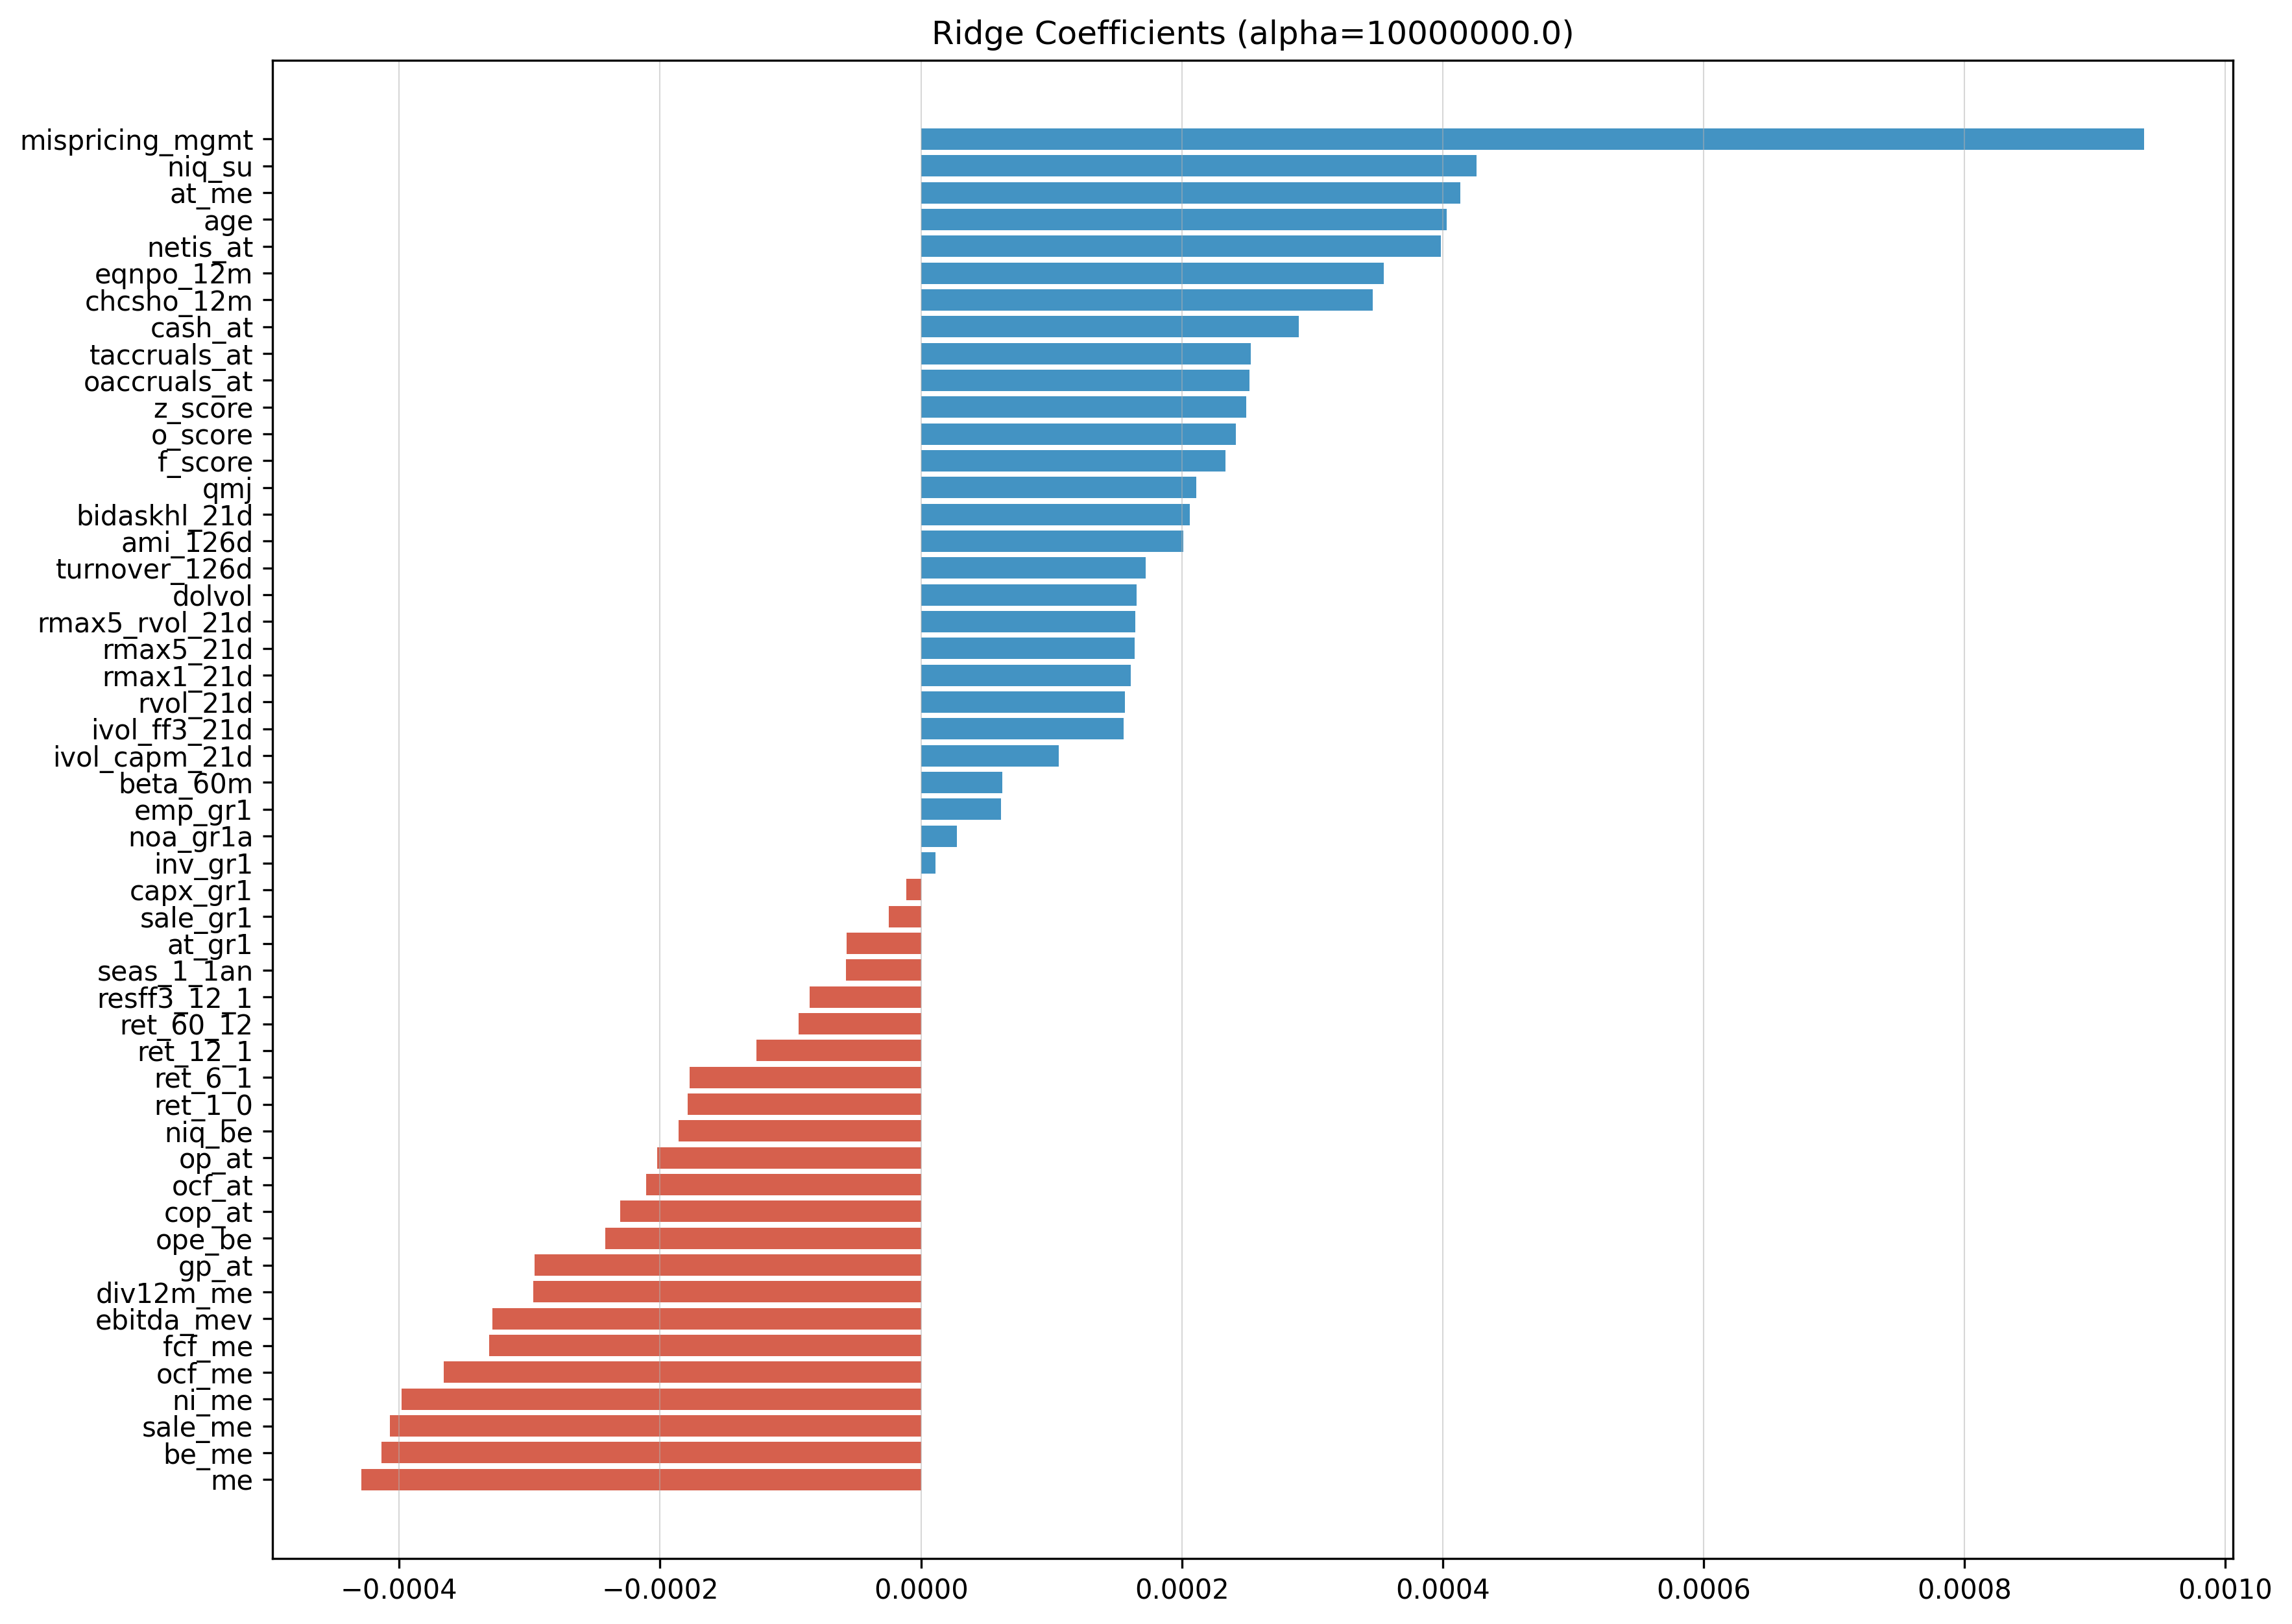

In [22]:
print_result()

ploted_coef = bst_ridge.coef_.copy()
ploted_coef.sort()
# print coefficients of ridge using horizontal bar chart
fig, axes = plt.subplots(figsize=(13, 10), dpi=300)
colors = ['#d6604d' if c < 0 else '#4393c3' for c in ploted_coef]
axes.grid(axis='x', lw=0.5, alpha=0.5)
axes.barh(X_train.columns, ploted_coef, color=colors)
axes.set_title(f"Ridge Coefficients (alpha={bst_alpha_ridge})")



# Feature Selection

1. Select 1~2 feature in each group with largest absolute value of coefficient. 
2. Draw correlation matrix for checking.
3. Make Interaction terms between each pair of selected features
4. fit new ridge model on dataset

Selected features: 
	- sale_me
	- ocf_me
	- cop_at
	- op_at
	- at_gr1
	- noa_gr1a
	- ret_1_0
	- ret_6_1
	- rmax5_rvol_21d
	- ivol_capm_21d
	- qmj
	- cash_at
	- niq_su


Text(0.5, 1.0, 'Correlation Matrix of Selected Features')

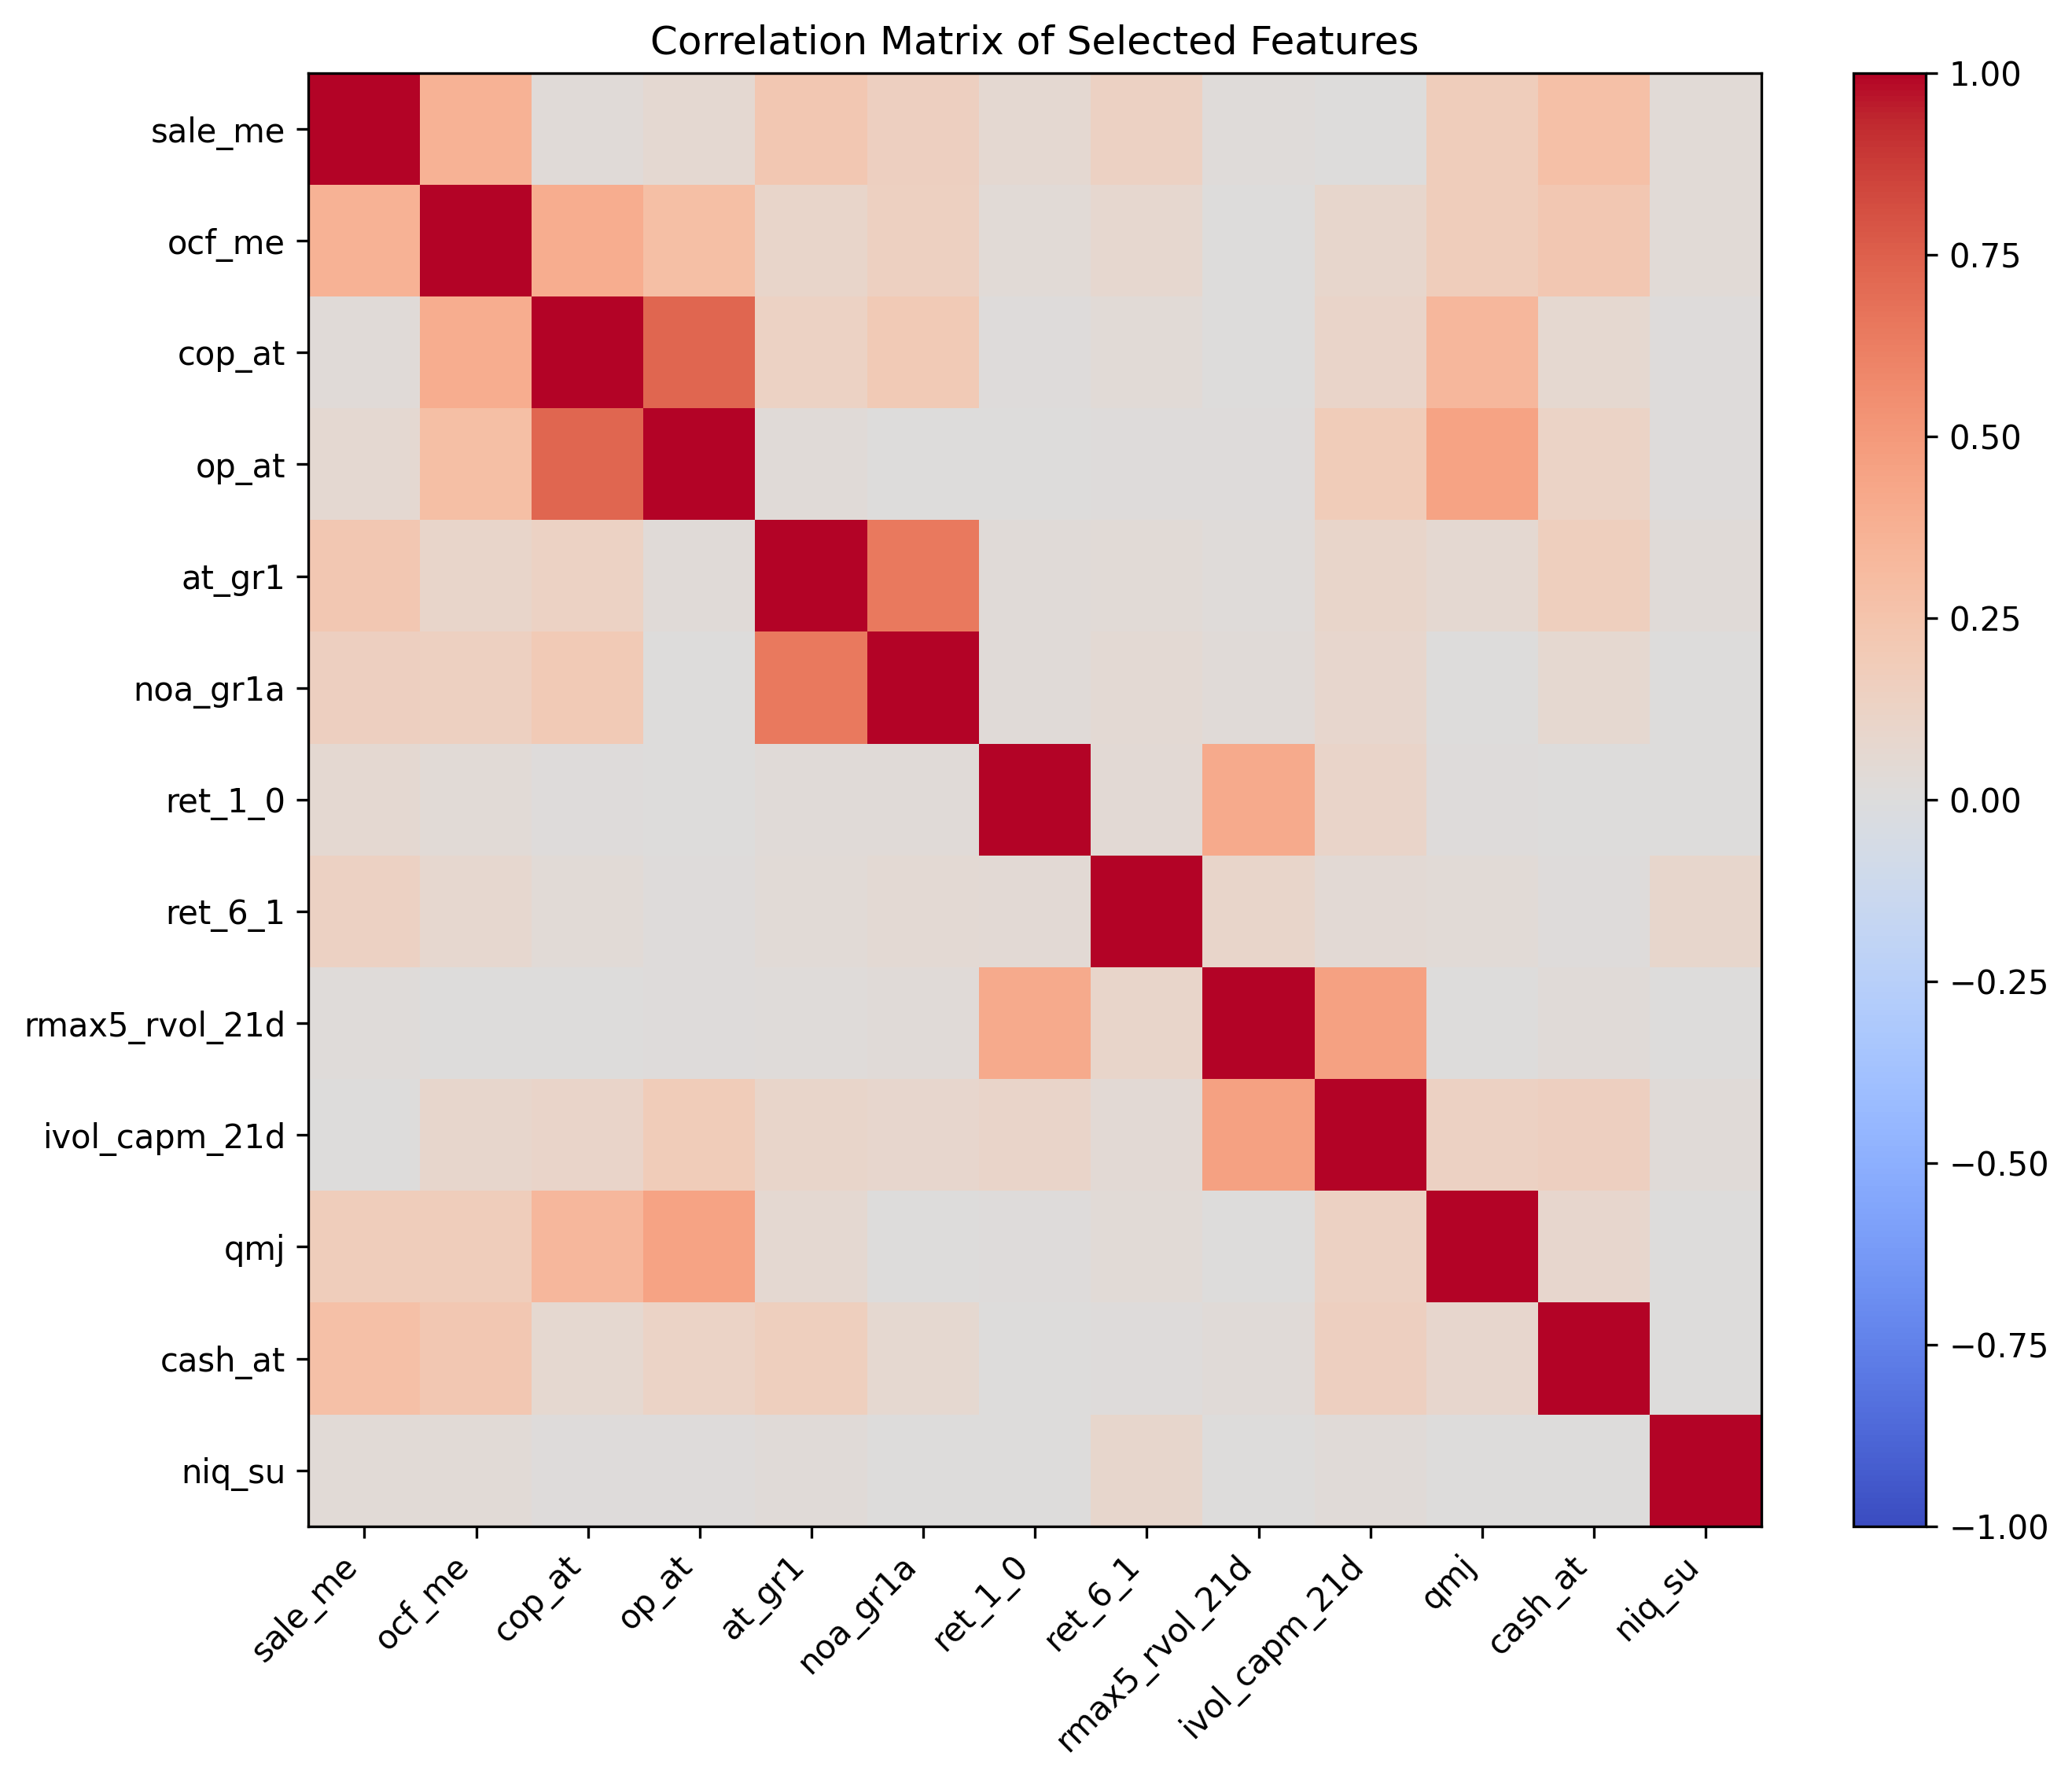

In [23]:
sel_feat = []

for grp, grp_df in preprocess_cfg.grp_idx.groupby(preprocess_cfg.grp_idx) :
    sorted_grp_df = grp_df.index.tolist()
    sorted_grp_df.sort(key=lambda x: abs(bst_ridge.coef_[X_train.columns.get_loc(x)]), reverse=True)
    # print(f"Group {grp}:")
    # for feature in sorted_grp_df[:min(len(sorted_grp_df), 4)] :
    #     coef = bst_ridge.coef_[X_train.columns.get_loc(feature)]
    #     print(f"  {feature:20s}: {coef:.4f}")
    sel_feat.extend(sorted_grp_df[: min(len(sorted_grp_df), preprocess_cfg.sel_num)])

print(f"Selected features: ", *sel_feat, sep='\n\t- ')

# compute correlation of each two features in sel_feat, and plot the correlation matrix as a heatmap
corr_matrix = X_train[sel_feat].corr().abs()
fig, axes = plt.subplots(figsize=(10, 8), dpi=300)
im = axes.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes.set_xticks(range(len(sel_feat)))
axes.set_xticklabels(sel_feat, rotation=45, ha='right')
axes.set_yticks(range(len(sel_feat)))
axes.set_yticklabels(sel_feat)
fig.colorbar(im, ax=axes)
axes.set_title("Correlation Matrix of Selected Features")

In [27]:
train_i = preprocess.make_intersactions(X_train, sel_feat)
val_i = preprocess.make_intersactions(X_val, sel_feat)
test_i = preprocess.make_intersactions(X_test, sel_feat)

X_train_i = pd.concat([X_train[sel_feat], train_i], axis=1)
X_val_i = pd.concat([X_val[sel_feat], val_i], axis=1)
X_test_i = pd.concat([X_test[sel_feat], test_i], axis=1)

X_trainval_i = pd.concat([X_train_i, X_val_i], ignore_index=True)

In [28]:
bst_sel_r2, bst_sel_sharpe, bst_sel_alpha = -np.inf, -np.inf, None
for alpha in tqdm(opt_ridge_alpha, desc='ridge_sel') :
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train[sel_feat], y_train)
    _, _, sharpe = compute_portfolio_metrics(val_df.assign(pred=ridge.predict(X_val[sel_feat])), 'pred', preprocess_cfg)
    r2 = oos_r2(y_val, ridge.predict(X_val[sel_feat]), y_null_val)
    if r2 > bst_sel_r2 :
        bst_sel_r2, bst_sel_sharpe, bst_sel_alpha = r2, sharpe, alpha

print(f"Ridge with selected features: best alpha: {bst_sel_alpha}")
bst_sel_ridge = Ridge(alpha=bst_sel_alpha)
bst_sel_ridge.fit(X_trainval[sel_feat], y_trainval)
preds['pred_ridge_sel'] = bst_sel_ridge.predict(X_test[sel_feat])

bst_i_r2, bst_i_sharpe, bst_i_alpha = -np.inf, -np.inf, None
for alpha in tqdm(opt_ridge_alpha, desc='ridge_i') :
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_i, y_train)
    _, _, sharpe = compute_portfolio_metrics(val_df.assign(pred=ridge.predict(X_val_i)), 'pred', preprocess_cfg)
    r2 = oos_r2(y_val, ridge.predict(X_val_i), y_null_val)
    if r2 > bst_i_r2 :
        bst_i_r2, bst_i_sharpe, bst_i_alpha = r2, sharpe, alpha

print(f"Ridge with selected features: best alpha: {bst_i_alpha}")
bst_i_ridge = Ridge(alpha=bst_i_alpha)
bst_i_ridge.fit(X_trainval_i, y_trainval)
preds['pred_ridge_i'] = bst_i_ridge.predict(X_test_i)

print_result(names=['ridge_sel', 'ridge_i'])

ridge_sel:   0%|          | 0/15 [00:00<?, ?it/s]

Ridge with selected features: best alpha: 10000000.0


ridge_i:   0%|          | 0/15 [00:00<?, ?it/s]

Ridge with selected features: best alpha: 10000000.0
Name         |     Ann. Ret |       Sharpe |           r2
---------------------------------------------------------
ridge_sel    |        5.54% |       1.1285 |       0.0001
ridge_i      |        4.73% |       1.2158 |      -0.0003


# Work Forward

Use the past $x\in\{2016, 2017, \dots, 2023\}$ years for training, then use $x+1$-th year for validation. Finally, apply on $x+2$-th year.